# **Exploratory Data Analysis — Project 2**

## **Step 1 — Import Libraries**

In [4]:
# Install libraries (only needed once)
!pip install pandas openpyxl matplotlib seaborn scipy

# Import them
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

## **Step 2 — Load the Dataset**

In [6]:
df = pd.read_excel('Dataset for Data Analytics.xlsx')
df['CouponCode'] = df['CouponCode'].fillna('NO_COUPON')
df['Date'] = pd.to_datetime(df['Date'])
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


## **Step 3 — Descriptive Statistics**

In [7]:
# Full statistical summary of all numeric columns
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


In [8]:
# See individual stats
print("Mean TotalPrice:",   df['TotalPrice'].mean())
print("Median TotalPrice:", df['TotalPrice'].median())
print("Std Dev:",           df['TotalPrice'].std())

Mean TotalPrice: 1053.9683
Median TotalPrice: 823.615
Std Dev: 819.8565583646451


In [9]:
# Count of each category
df['Product'].value_counts()
df['OrderStatus'].value_counts()
df['PaymentMethod'].value_counts()
df['ReferralSource'].value_counts()

ReferralSource
Instagram    259
Email        250
Google       241
Facebook     228
Referral     222
Name: count, dtype: int64

## **Step 4 — Trend Analysis**

In [11]:
# Create a Month column
df['Month'] = df['Date'].dt.to_period('M')

# Group by month and sum revenue
monthly_revenue = df.groupby('Month')['TotalPrice'].sum()
print(monthly_revenue)

Month
2023-01    56685.75
2023-02    40117.66
2023-03    48609.37
2023-04    27751.71
2023-05    63836.84
2023-06    49500.19
2023-07    42820.66
2023-08    54352.14
2023-09    29526.67
2023-10    52607.85
2023-11    43079.67
2023-12    43754.73
2024-01    38528.08
2024-02    36909.57
2024-03    36030.90
2024-04    49613.14
2024-05    27909.11
2024-06    68068.54
2024-07    42963.98
2024-08    31991.07
2024-09    39794.98
2024-10    37226.97
2024-11    32413.76
2024-12    38785.77
2025-01    29099.40
2025-02    35317.55
2025-03    39200.66
2025-04    31821.20
2025-05    43396.64
2025-06    53047.40
Freq: M, Name: TotalPrice, dtype: float64


In [12]:
# Revenue by Product
df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False)

Product
Chair      195620.11
Printer    195612.61
Laptop     192126.56
Tablet     186568.95
Monitor    175651.41
Desk       167459.93
Phone      151722.39
Name: TotalPrice, dtype: float64

## **Step 5 — Outlier Detection**

### **Method 1 — IQR (Best for business data)**

In [14]:
Q1  = df['TotalPrice'].quantile(0.25)   # 25th percentile
Q3  = df['TotalPrice'].quantile(0.75)   # 75th percentile
IQR = Q3 - Q1                           # Interquartile Range

lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR

# Find outliers
outliers = df[(df['TotalPrice'] < lower_fence) | (df['TotalPrice'] > upper_fence)]
print(f"Number of outliers: {len(outliers)}")
print(outliers[['OrderID', 'TotalPrice']])

Number of outliers: 8
        OrderID  TotalPrice
107   ORD200107     3353.75
326   ORD200326     3352.40
328   ORD200328     3370.20
469   ORD200469     3384.90
632   ORD200632     3390.80
789   ORD200789     3456.40
1065  ORD201065     3334.00
1122  ORD201122     3390.95


### **Method 2 — Z-Score (Best for normally distributed data)**

In [15]:
from scipy import stats

z_scores = np.abs(stats.zscore(df['TotalPrice']))
outliers_z = df[z_scores > 3]
print(f"Z-Score outliers: {len(outliers_z)}")

Z-Score outliers: 0


## **Step 6 — Correlation Analysis**

In [16]:
# Correlation between all numeric columns
df[['TotalPrice', 'UnitPrice', 'Quantity', 'ItemsInCart']].corr()

,TotalPrice,UnitPrice,Quantity,ItemsInCart
TotalPrice,1.000000,0.717081,0.615251,0.392540
UnitPrice,0.717081,1.000000,0.014553,0.000602
Quantity,0.615251,0.014553,1.000000,0.650061
ItemsInCart,0.392540,0.000602,0.650061,1.000000


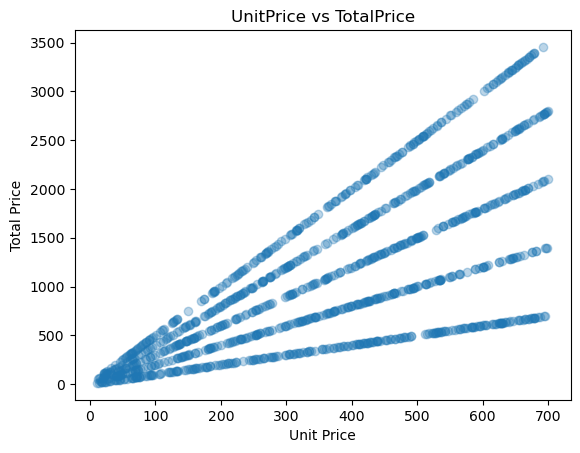

In [17]:
# Scatter plot to visualize it
plt.scatter(df['UnitPrice'], df['TotalPrice'], alpha=0.3)
plt.xlabel('Unit Price')
plt.ylabel('Total Price')
plt.title('UnitPrice vs TotalPrice')
plt.show()

## **Step 7 — Making Charts**

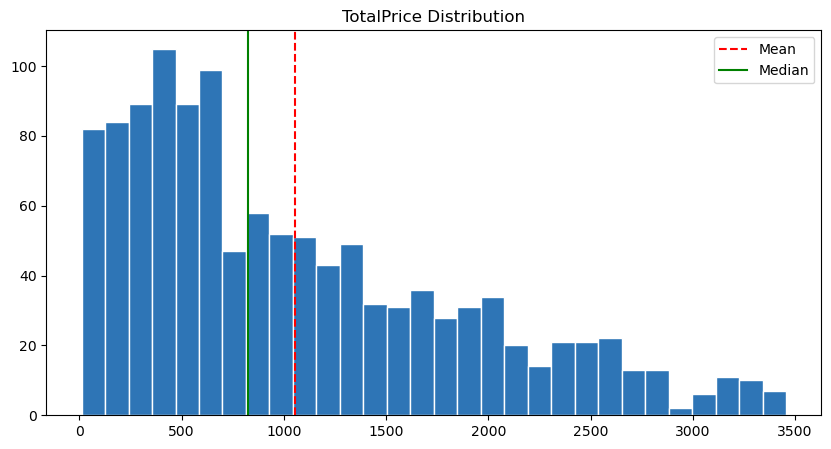

In [19]:
# Histogram — distribution of TotalPrice
plt.figure(figsize=(10, 5))
plt.hist(df['TotalPrice'], bins=30, color='#2E75B6', edgecolor='white')
plt.axvline(df['TotalPrice'].mean(),   color='red',   linestyle='--', label='Mean')
plt.axvline(df['TotalPrice'].median(), color='green', linestyle='-',  label='Median')
plt.legend()
plt.title('TotalPrice Distribution')
plt.show()

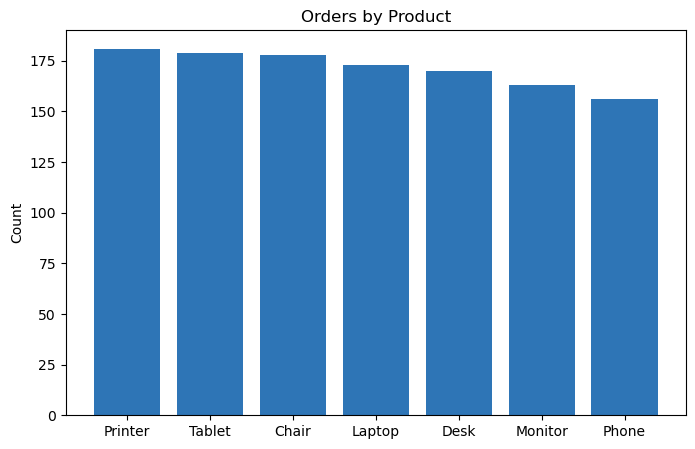

In [20]:
# Bar chart — orders by product
product_counts = df['Product'].value_counts()
plt.figure(figsize=(8, 5))
plt.bar(product_counts.index, product_counts.values, color='#2E75B6')
plt.title('Orders by Product')
plt.ylabel('Count')
plt.show()

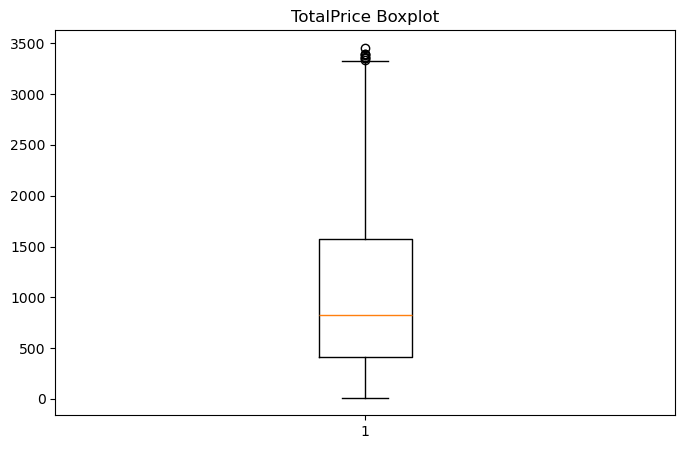

In [21]:
# Boxplot — spot outliers visually
plt.figure(figsize=(8, 5))
plt.boxplot(df['TotalPrice'])
plt.title('TotalPrice Boxplot')
plt.show()

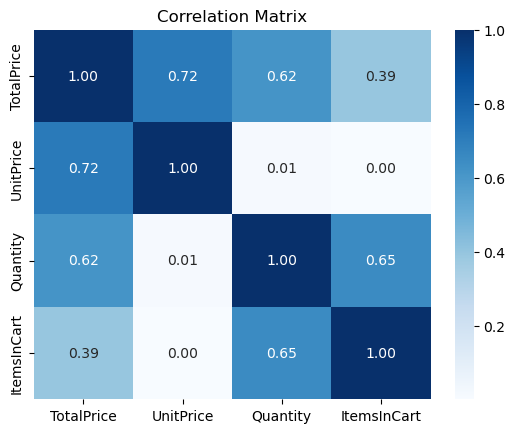

In [22]:
# Heatmap — correlation matrix
corr = df[['TotalPrice','UnitPrice','Quantity','ItemsInCart']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues')
plt.title('Correlation Matrix')
plt.show()

## **Step 8 — Export to Excel**

In [23]:
# Save your analysis results to Excel
with pd.ExcelWriter('EDA_Report.xlsx') as writer:
    
    # Sheet 1 - Descriptive stats
    df.describe().to_excel(writer, sheet_name='Descriptive Stats')
    
    # Sheet 2 - Monthly revenue
    monthly_revenue.to_excel(writer, sheet_name='Monthly Revenue')
    
    # Sheet 3 - Product revenue
    prod_rev = df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False)
    prod_rev.to_excel(writer, sheet_name='Product Revenue')

print("Excel saved!")

Excel saved!
